In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
#Read the data
df=pd.read_csv("Reviews.csv")
#top 5 rows of the data
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
#Understand the data types of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [4]:
#Looking at the summary of the reviews
df.Summary.head(5)

0    Good Quality Dog Food
1        Not as Advertised
2    "Delight" says it all
3           Cough Medicine
4              Great taffy
Name: Summary, dtype: str

In [5]:
#Looking at the description of the reviews
df.Text.head(5)

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
Name: Text, dtype: str

Step 2-3:Preprocess the data

In [6]:
#Import libraraies
from ast import Lambda

from nltk.corpus import stopwords
from textblob import TextBlob
from textblob import Word
#Lower casing and removing the stop words
df['Text']=df['Text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
df['Text']=df['Text'].str.replace('[^\w\s]','')
df.Text.head(5)

<>:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\Akshara\AppData\Local\Temp\ipykernel_1120\882634651.py:9: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  df['Text']=df['Text'].str.replace('[^\w\s]','')


0    i have bought several of the vitality canned d...
1    product arrived labeled as jumbo salted peanut...
2    this is a confection that has been around a fe...
3    if you are looking for the secret ingredient i...
4    great taffy at a great price. there was a wide...
Name: Text, dtype: str

In [9]:
print(df['Text'].isnull().sum())
print(df['Text'].dtype)

0
str


In [ ]:
#Fill the missing values
df['Text']=df['Text'].fillna('')

In [11]:
#Convert everything to string
df['Text']=df['Text'].astype(str)

In [12]:
#Then remove stopwords
stop = set(stopwords.words('english'))
df['Text']=df['Text'].apply(lambda text: ' '.join(word for word in text.split() if word.lower() not in stop))

In [13]:
#Removal of stop words
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = stopwords.words('english')
df['Text']=df['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))
df.Text.head(5)

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanuts.....
2    confection around centuries. light, pillowy ci...
3    looking secret ingredient robitussin believe f...
4    great taffy great price. wide assortment yummy...
Name: Text, dtype: str

In [14]:
#Spelling correction
df['Text']=df['Text'].astype(str)
sample = df['Text'].head(100)
corrected = sample.apply(lambda x:str(TextBlob(x).correct()))
print(corrected.head())

0    bought several vitality canned dog food produc...
1    product arrived labelled lumbo halted peanuts....
2    connection around centuries. light, pillow cit...
3    looking secret ingredient robitussin believe f...
4    great staff great price. wide assortment mummy...
Name: Text, dtype: str


In [15]:
df=df.head(500)

In [16]:
#Lemmatization
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = nltk.WordNetLemmatizer()
df['Text']=df['Text'].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))
df.Text.head(5)

[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanuts.....
2    confection around centuries. light, pillowy ci...
3    looking secret ingredient robitussin believe f...
4    great taffy great price. wide assortment yummy...
Name: Text, dtype: str

Step 2-4: Analyze data
This step is not connected anywhere in predicting sentiments;what we are trying to do here is to dig deeper into the data and understand it.

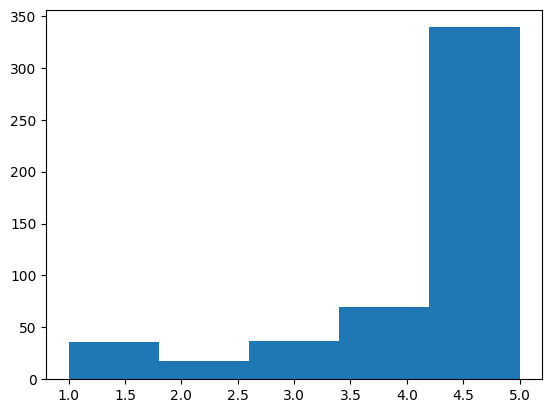

Score
1     36
2     18
3     37
4     70
5    339
Name: Id, dtype: int64


In [17]:
#Create a new data frame "reviews" to perform exploratory data anlysis upon that
reviews=df
#Dropping null values
reviews.dropna(inplace=True)
#The histogram reveals this dataset is highly unbalanced towards high rating.
reviews.Score.hist(bins=5,grid=False)
plt.show()
print(reviews.groupby('Score').count().Id)

In [18]:
reviews['Score'].value_counts()

Score
5    339
4     70
3     37
1     36
2     18
Name: count, dtype: int64

In [19]:
min_count=reviews['Score'].value_counts().min()
min_count

np.int64(18)

In [20]:
#To make it balanced data,we sampled each score by the lowest n-count from above.
score_1=reviews[reviews['Score']==1].sample(n=18)
score_2=reviews[reviews['Score']==2].sample(n=18)
score_3=reviews[reviews['Score']==3].sample(n=18)
score_4=reviews[reviews['Score']==4].sample(n=18)
score_5=reviews[reviews['Score']==5].sample(n=18)
#Here we recreate a 'balanced' dataset.
                                           

In [21]:
#Here we create a 'balanced' dataset.
reviews_sample=pd.concat([score_1,score_2,score_3,score_4,score_5],axis=0)
#reviews_sample.Score.value_counts()
reviews_sample.reset_index(inplace=True,drop=True)

In [22]:
#Printing count by 'Score' to check dataset is now balanced
print(reviews_sample.groupby('Score').count().Id)

Score
1    18
2    18
3    18
4    18
5    18
Name: Id, dtype: int64


In [26]:
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable


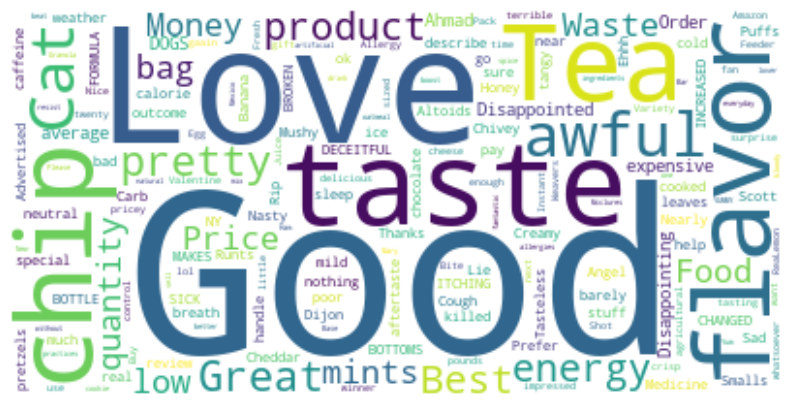

In [32]:
#let's build work cloud looking at the 'Summary' text
from wordcloud import WordCloud
from wordcloud import STOPWORDS
#Wordcloud function's input needs to be a single string of text.
#Here I'm concatenating all Summaries into a single string.
#similarily you can build for Text column
reviews_str = reviews_sample.Summary.str.cat(sep=' ')
wordcloud=WordCloud(background_color='white').generate(reviews_str)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [33]:
#Now let's split the data into Negative (Score is 1 or 2) and Positive(4 or #5) Reviews.
negative_reviews= reviews_sample[reviews_sample['Score'].isin([1,2])]
positive_reviews=reviews_sample[reviews_sample['Score'].isin([4,5])]
#Transform to single string
negative_reviews_str = negative_reviews.Summary.str.cat()
positive_reviews_str = positive_reviews.Summary.str.cat()
#Create workclouds
wordcloud_negative = WordCloud(background_color='white').generate(negative_reviews_str)
wordcloud_positive = WordCloud(background_color = 'white').generate(positive_reviews_str)


Text(0.5, 1.0, 'Reviews with Negative Scores')

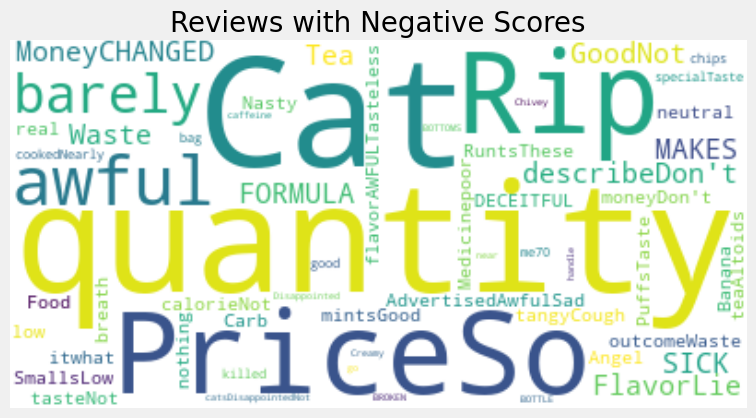

In [ ]:
#Plot
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(211)
ax1.imshow(wordcloud_negative,interpolation='bilinear')
ax1.axis()
ax1.set_title('Reviews with Negative Scores',fontsize=20)

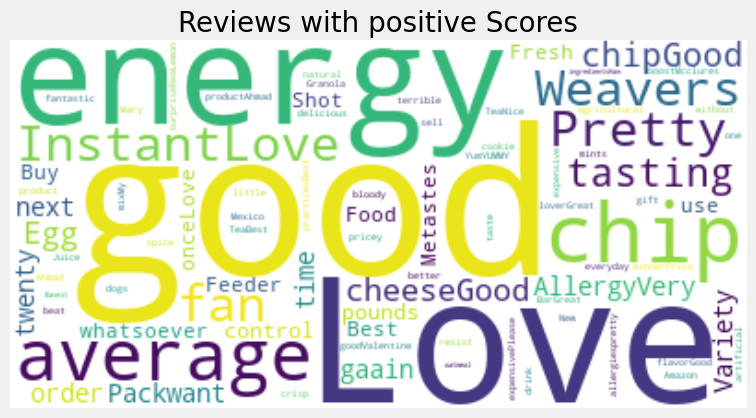

In [48]:
fig = plt.figure(figsize=(10,10))
import matplotlib.pyplot as plt
ax2 = fig.add_subplot(212)
ax2.imshow(wordcloud_positive,interpolation='bilinear')
ax2.axis("off")
ax2.set_title('Reviews with positive Scores',fontsize=20)
plt.show()


Step 2-5 .Use a pre-trained model


Step 2-6.Do sentiment Analysis
In sentiment analysis pre-trained model takes the input from the text description and outputs the sentiment score ranging from -1 to +1 for each sentence.


In [37]:
pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [51]:
#Importing required libraries
import pandas as pdi
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import os
import sys
import ast
plt.style.use('fivethirtyeight')
#Function for getting the sentiment
cp=sns.color_palette()
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
#Generating sentiment for all the sentence present in the dataset
emptyline=[]
for row in df['Text']:
    vs=analyzer.polarity_scores(row)
    emptyline.append(vs)

#creating new dataframe with sentiments
df_sentiments=pd.DataFrame(emptyline)
df_sentiments.head(5)

,neg,neu,pos,compound
0,0.000,0.517,0.483,0.9413
1,0.129,0.762,0.110,-0.1027
2,0.123,0.608,0.268,0.8532
3,0.000,0.868,0.132,0.4404
4,0.000,0.369,0.631,0.9468


In [53]:
#Merging the sentiments back to reviews dataframe
df_c=pd.concat([df.reset_index(drop=True),df_sentiments],axis=1)
df_c.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,neg,neu,pos,compound
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,bought several vitality canned dog food produc...,0.000,0.517,0.483,0.9413
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled jumbo salted peanuts.....,0.129,0.762,0.110,-0.1027
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","confection around centuries. light, pillowy ci...",0.123,0.608,0.268,0.8532


In [55]:
#Convert scores into positive and negative sentiments using some threshold 
df_c['sentiment']=np.where(df_c['compound']>=0,'positive','Negative')
df_c.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,neg,neu,pos,compound,sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,bought several vitality canned dog food produc...,0.000,0.517,0.483,0.9413,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled jumbo salted peanuts.....,0.129,0.762,0.110,-0.1027,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","confection around centuries. light, pillowy ci...",0.123,0.608,0.268,0.8532,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,looking secret ingredient robitussin believe f...,0.000,0.868,0.132,0.4404,positive
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy great price. wide assortment yummy...,0.000,0.369,0.631,0.9468,positive


STEP 2-7.GET BUSINESS INSIGHTS
Let's see hiw overall sentiment is using the sentiment we generated

<Axes: xlabel='sentiment'>

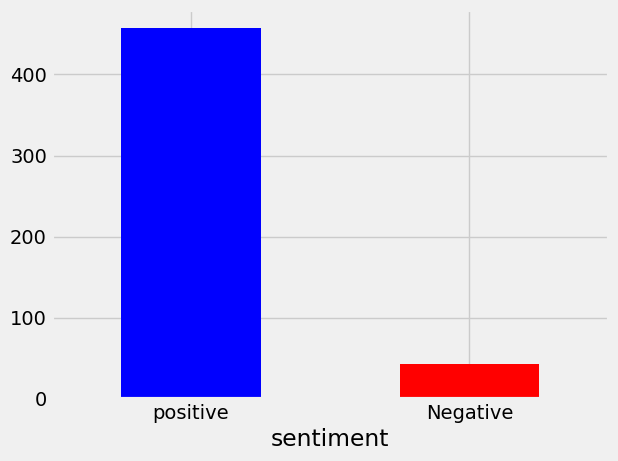

In [62]:
result=df_c['sentiment'].value_counts()
result.plot(kind='bar',rot = 0,color=['b','r'])

<Axes: xlabel='ProductId'>

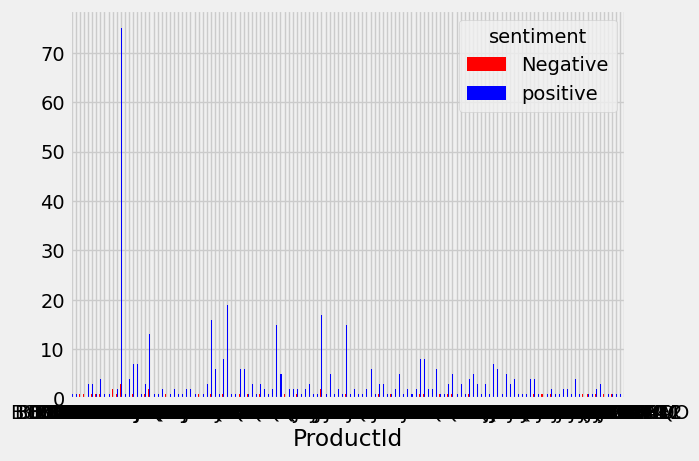

In [67]:
#Sample code snippet
result=df_c.groupby('ProductId')['sentiment'].value_counts().unstack()
result[['Negative','positive']].plot(kind='bar',rot=0,color=['r','b'])